<a href="https://colab.research.google.com/github/garavels/ECON-148/blob/main/notebooks/housing_nowcast_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Local Housing Price Nowcasting
## Econ 148 — Group Project

### Project Overview
We nowcast local housing prices using high-frequency indicators
such as mortgage rates, Google Trends search volume, and listing
data.

## 0. Setup
We mount Google Drive and install any non-default packages needed
to run this notebook. All teammates must have the shared folder
shortcutted to their My Drive root.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/econ148_housing_nowcast/'

!pip install pytrends pandas-datareader --quiet

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pytrends.request import TrendReq
import pandas_datareader.data as web
import requests
from datetime import datetime

pd.set_option('display.max_columns', 50)

## 1. Configuration
We define our API key, metropolitan focus and data range

In [4]:
FRED_API_KEY = '129bb2a573747a582445a0c8ece401e7'
METROS = {
    'Bay Area': 'SFXRSA',
    'Austin':   'AUXRSA',
    'Cleveland':'CLEXRSA'
}
START_DATE = '2018-01-01'
END_DATE = '2024-12-31'

## 2. Data Collection - FRED Macro Indicators

We choose mortage rates and unemployment rates as our main economic indicators for nowcasting in each metropolitan area. We pull them from the FRED API using pandas_datareader. Each city has its own FRED series code.

In [5]:
import pandas_datareader.data as web

def fetch_fred_series(series_id, start, end, api_key):
    df = web.DataReader(series_id, 'fred', start, end,
                       api_key=api_key)
    return df

mortgage = fetch_fred_series('MORTGAGE30US',
                              START_DATE,
                              END_DATE,
                              FRED_API_KEY)

print(mortgage.head())
print(mortgage.shape)

            MORTGAGE30US
DATE                    
2018-01-04          3.95
2018-01-11          3.99
2018-01-18          4.04
2018-01-25          4.15
2018-02-01          4.22
(365, 1)


In [9]:
unemployment_series = {
    'Bay Area' : 'SANF806UR',
    'Austin'   : 'AUST448UR',
    'Cleveland': 'CLEV439UR'
}

def fetch_unemployment(series_dict, start, end, api_key):
    frames = {}
    for city, code in series_dict.items():
        df = web.DataReader(code, 'fred', start, end,
                           api_key=api_key)
        frames[city] = df
    return frames

unemployment = fetch_unemployment(unemployment_series,
                                   START_DATE,
                                   END_DATE,
                                   FRED_API_KEY)

for city, df in unemployment.items():
    print(city, df.shape)

Bay Area (84, 1)
Austin (84, 1)
Cleveland (84, 1)


## 2.3 Zillow Home Value Index (ZHVI) - Target Variable

Our target variable is Zillow ZHVI. So we load the dataset. This indicator represents the typical home value for each metropolitan area chosen. We filter the databse for our three chosen cities and data range.

In [10]:
ZHVI_URL = (
    "https://files.zillowstatic.com/research/public_csvs"
    "/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
)

def load_zhvi(url):
    df = pd.read_csv(url)
    return df

def filter_zhvi(df, regions):
    mask = df['RegionName'].isin(regions)
    return df[mask].reset_index(drop=True)

zhvi_raw = load_zhvi(ZHVI_URL)
regions = [
    'San Francisco, CA',
    'Austin, TX',
    'Cleveland, OH'
]
zhvi = filter_zhvi(zhvi_raw, regions)
print(zhvi[['RegionName']].values)
print(zhvi.shape)

[['San Francisco, CA']
 ['Austin, TX']
 ['Cleveland, OH']]
(3, 320)


## 2.4 Reshaping ZHVI Data

We use merge to reshape the current ZHVI dataframe from wide format (one column per date) to long format (one row per city per month) and merge it with our other data sources.

In [11]:
def melt_zhvi(df):
    id_cols = ['RegionName']
    date_cols = [c for c in df.columns if c.startswith('20')]
    melted = df[id_cols + date_cols].melt(
        id_vars=id_cols,
        var_name='date',
        value_name='zhvi'
    )
    melted['date'] = pd.to_datetime(melted['date'])
    return melted

def filter_dates(df, start, end):
    mask = (df['date'] >= start) & (df['date'] <= end)
    return df[mask].reset_index(drop=True)

zhvi_long = melt_zhvi(zhvi)
zhvi_long = filter_dates(zhvi_long, START_DATE, END_DATE)
print(zhvi_long.head())
print(zhvi_long.shape)

          RegionName       date           zhvi
0  San Francisco, CA 2018-01-31  891368.733354
1         Austin, TX 2018-01-31  306435.593320
2      Cleveland, OH 2018-01-31  140856.652120
3  San Francisco, CA 2018-02-28  903031.910090
4         Austin, TX 2018-02-28  307370.607298
(252, 3)


## 2.5 Merging All Data Sources
We now merge ZHVI, mortgage rates, and unemployment into one
dataframe. Mortgage rates are national so they apply to
all three cities equally.

In [18]:
def resample_monthly(df, col_name):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.resample('MS').mean().reset_index()
    df.columns = ['date', col_name]
    return df

def prep_unemployment(unemp, city):
    u = unemp[city].reset_index()
    u.columns = ['date', 'unemployment']
    u['date'] = u['date'].dt.to_period('M').dt.to_timestamp()
    return u

def merge_city_data(zhvi, mortgage, unemp, region, city):
    city_df = zhvi[zhvi['RegionName'] == region].copy()
    city_df['date'] = city_df['date'].dt.to_period('M').dt.to_timestamp()
    mort = resample_monthly(mortgage, 'mortgage_rate')
    city_df = city_df.merge(mort, on='date', how='left')
    u = prep_unemployment(unemp, city)
    return city_df.merge(u, on='date', how='left')

print("Functions defined successfully")

Functions defined successfully


## 2.6 Building the Final Dataset
We apply the merge function to all three cities and
combine them into one final dataframe for analysis.

In [20]:
city_map = {
    'San Francisco, CA': 'Bay Area',
    'Austin, TX':        'Austin',
    'Cleveland, OH':     'Cleveland'
}

def build_master(zhvi, mortgage, unemployment, city_map):
    frames = []
    for region, city in city_map.items():
        df = merge_city_data(zhvi, mortgage,
                             unemployment, region, city)
        df['city'] = city
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

master = build_master(zhvi_long, mortgage,
                      unemployment, city_map)
print(master.shape)
print(master.head())

(252, 6)
          RegionName       date           zhvi  mortgage_rate  unemployment  \
0  San Francisco, CA 2018-01-01  891368.733354         4.0325           3.0   
1  San Francisco, CA 2018-02-01  903031.910090         4.3300           2.9   
2  San Francisco, CA 2018-03-01  912947.559992         4.4440           2.9   
3  San Francisco, CA 2018-04-01  921487.145661         4.4675           2.8   
4  San Francisco, CA 2018-05-01  930626.084332         4.5860           2.8   

       city  
0  Bay Area  
1  Bay Area  
2  Bay Area  
3  Bay Area  
4  Bay Area  


## 3. Exploratory Data Analysis
We first visualize ZHVI trends across all three metropoltian areas chosen to understand dynamics before modeling. This helps us visualize and understand structural differences between cities.


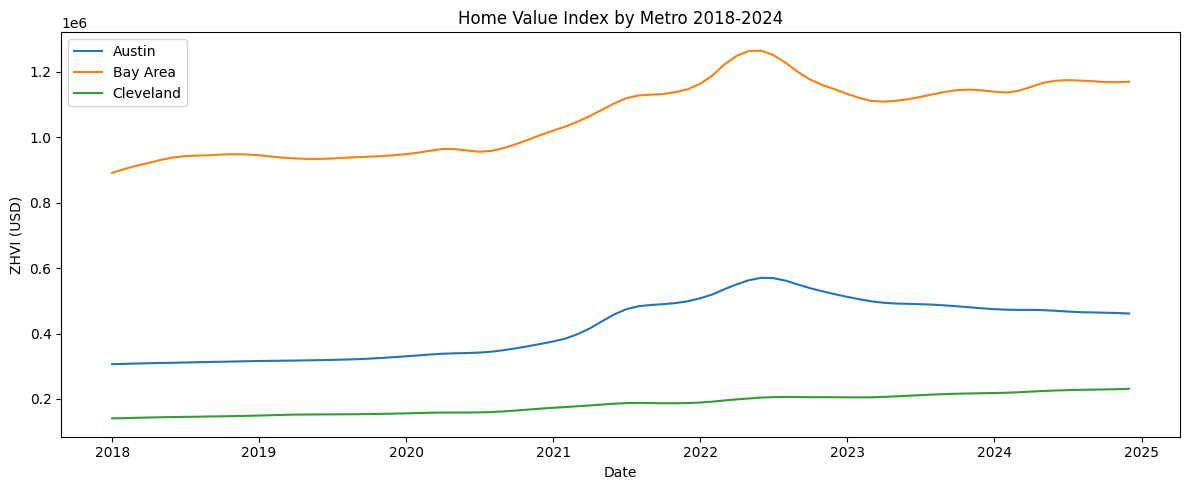

In [21]:
def style_zhvi_plot(ax):
    ax.set_title('Home Value Index by Metro 2018-2024')
    ax.set_xlabel('Date')
    ax.set_ylabel('ZHVI (USD)')
    ax.legend()

def plot_zhvi(df):
    fig, ax = plt.subplots(figsize=(12, 5))
    for city, group in df.groupby('city'):
        ax.plot(group['date'], group['zhvi'], label=city)
    style_zhvi_plot(ax)
    plt.tight_layout()
    plt.show()

plot_zhvi(master)

## 3.2 Mortgage Rate vs Home Values
We plot mortgage rates alongside ZHVI to vizualize the relationship between rates and prices. We should observe an inverse relationship between both variables.

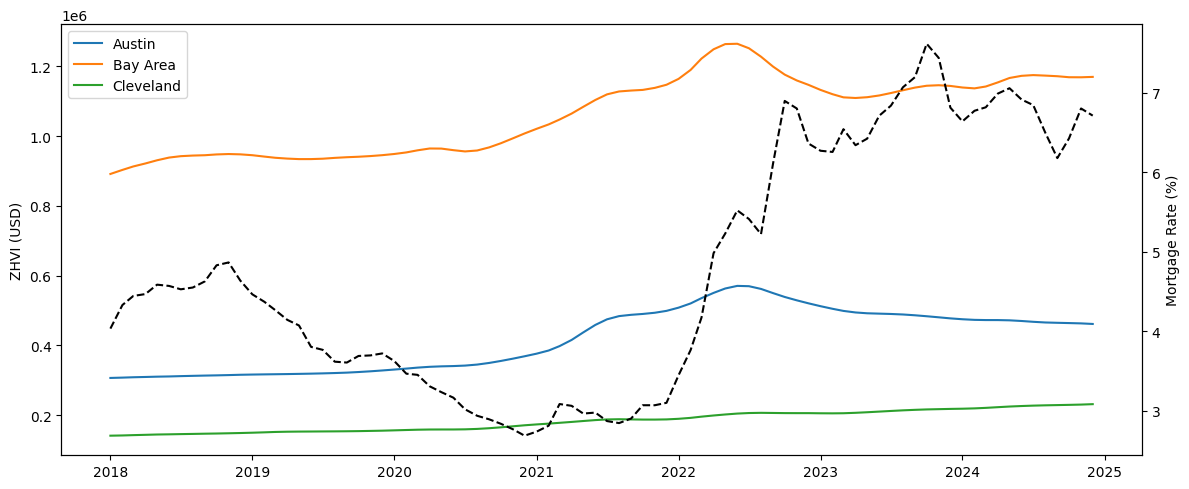

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
bay = master[master['city'] == 'Bay Area']

for city, group in master.groupby('city'):
    ax1.plot(group['date'], group['zhvi'], label=city)

ax2.plot(bay['date'], bay['mortgage_rate'],
         color='black', linestyle='--', label='Mortgage Rate')
ax1.set_ylabel('ZHVI (USD)')
ax2.set_ylabel('Mortgage Rate (%)')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3.3 Correlation Between Features and ZHVI

To understand which variables matter most in each market, we compute the correlation between mortgage rates, unemployment, and ZHVI for each city separately.

In [23]:
cols = ['zhvi', 'mortgage_rate', 'unemployment']

for city, group in master.groupby('city'):
    print(f"\n{city}")
    print(group[cols].corr().round(2))


Austin
               zhvi  mortgage_rate  unemployment
zhvi           1.00           0.52         -0.16
mortgage_rate  0.52           1.00         -0.33
unemployment  -0.16          -0.33          1.00

Bay Area
               zhvi  mortgage_rate  unemployment
zhvi           1.00           0.54         -0.12
mortgage_rate  0.54           1.00         -0.40
unemployment  -0.12          -0.40          1.00

Cleveland
               zhvi  mortgage_rate  unemployment
zhvi           1.00           0.72         -0.30
mortgage_rate  0.72           1.00         -0.47
unemployment  -0.30          -0.47          1.00
